# 03 . Neuran Network Classification With pytorch.

In [ ]:
import sklearn
from sklearn.datasets import make_circles

In [ ]:
# make 1000 samples
n_samples = 1000

# create circles

x, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [ ]:
len(x), len(y)

(1000, 1000)

In [ ]:
print(f"First 5 samples of x:\n {x[:5]}")
print(f"First 5 samples of y:\n {y[:5]}")

First 5 samples of x:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:
 [1 1 1 1 0]


In [ ]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [ ]:
x

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [ ]:
# make a data frames of circle data
import pandas as pd
circles = pd.DataFrame({"x1": x[:, 0],
                        "x2": x[:, 1],
                        "labels": y})
circles.head(10)

,x1,x2,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [ ]:
circles.labels

,labels
0,1
1,1
2,1
3,1
4,0
...,...
995,0
996,0
997,1
998,0


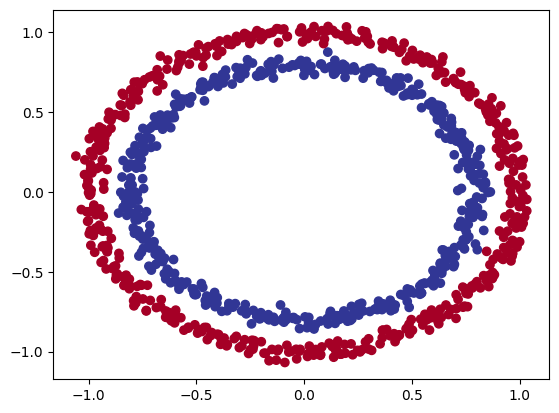

In [ ]:
# visualize, visualize, visualize
import matplotlib.pyplot as plt
plt.scatter(x=x[:, 0],
            y=x[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

### 1.1 Checking input and output shapes

In [ ]:
x.shape, y.shape

((1000, 2), (1000,))

In [ ]:
x

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [ ]:
# view the firs example of features labels
x_sample =x[0]
y_sample =y[0]

print(f"Values for one sample of x: {x_sample} and the same for y {y_sample}")
print(f"Shapes for one sample of x: {x_sample.shape} and the same for y: {y_sample.shape}")


Values for one sample of x: [0.75424625 0.23148074] and the same for y 1
Shapes for one sample of x: (2,) and the same for y: ()


### 1.2 Turn data in to tensors and create train and test split

In [ ]:
import torch
torch.__version__

'2.10.0+cu128'

In [ ]:
type(x)

numpy.ndarray

In [ ]:
# Turn data into tensors
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)


x[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
type(x), x.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [ ]:
# Split data into training and testing set
from sklearn.model_selection import train_test_split

x_train,x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size = 0.2, # 0.2 = 20% of data will be test & 80% train
                                                    random_state = 42)

In [ ]:
len(x_train), len(x_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [ ]:
n_samples

1000

### Building a Model

In [ ]:
# 2. Building a model
import torch
from torch import nn

# make device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
x_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

let's create a model that:

1. subclasses
2.create 2 nn.Linear()
3.Define a forward()
4.instantiate


In [ ]:
# 1. construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
  def __int__():
    super().__init__()
    # 2. create 2 nn.Linear layer capable of handling the shape of our data
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x))

model_0 = CircleModelV0().to(device)
model_0



CircleModelV0()

In [ ]:
# let's replicate the model above using nn. linear()
model_0 = nn.Sequential(
  nn.Linear(in_features=2, out_features=5),
  nn.Linear(in_features=5, out_features=1)

).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]], device='cuda:0')),
             ('0.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='cuda:0')),
             ('1.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='cuda:0')),
             ('1.bias', tensor([-0.2060], device='cuda:0'))])

In [ ]:
# make some predictions
untrained_preds = model_0(x_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(x_test)}, shape: {x_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"Length of 10 Lables:\n{y_test[:10]}")

Length of predictions: 200, shape: torch.Size([200, 1])
Length of test samples: 200, shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667],
        [-0.1484],
        [-0.0826],
        [-0.0946],
        [-0.1918],
        [-0.0944]], device='cuda:0', grad_fn=<SliceBackward0>)
Length of 10 Lables:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
x_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Setup loss function and optimizer

In [ ]:
# setup loss function
#loss_fn = nn.BCELOSS()
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [ ]:
# calculate accuracy - out of 100 examples , what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc =(correct/len(y_true))*100
  return acc


### 3.Train a Model

1.Forward pass
2.Calculate the loss
3.Optimizer zero grad
4.Loss backward(backpropagation)
5.Optimizer step(gradient decent)

#### 3.1 Going from raw logits

In [ ]:
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
# view the first 5 output of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(x_test.to(device))[:5]

y_logits

tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]], device='cuda:0')

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
# use the sigmoid activation function on our model logits to turn them into predictions
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4683],
        [0.4758],
        [0.4524],
        [0.4728],
        [0.4584]], device='cuda:0')

In [ ]:
epochs = 200
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')

for our prediction probabitity values, we need to perform a range-style rounding on them:

In [ ]:
# find the predicted labels
y_preds = torch.round(y_pred_probs)

# in full
y_pred_labels = torch.round(torch.sigmoid(model_0(x_test.to(device))[:5]))

# check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get grid of extra dimension
y_preds.squeeze()


tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### 3.1 Building a Training and Testing Loop

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 300
# set data to target device
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

# build training and evaluation loop
for epoch in range(epochs):
  ### Training
  model_0.train()

  # 1.Forward pass
  y_logits = model_0(x_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits


  # 2. calculate loss/accuracy
  loss = loss_fn(torch.sigmoid(y_logits),
                 y_train)
  loss = loss_fn(y_logits,
                y_train )
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  # 3. potimizer zero grad
  optimizer.zero_grad()

  # 4. loss backward
  loss.backward()

  # 5. optimizer step
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():

    # 1. Forward pass
    test_logits = model_0(x_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. calculate test loss/acc
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

    # print out what's happening

    if epoch % 10 ==0:
      print(f"Epoch: {loss:.5f} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:5f}, Test acc: {test_acc:.2f}%")


Epoch: 0.69569 | Loss: 0.69569, Acc: 50.00% | Test Loss: 0.697212, Test acc: 50.00%
Epoch: 0.69403 | Loss: 0.69403, Acc: 50.00% | Test Loss: 0.696154, Test acc: 50.00%
Epoch: 0.69343 | Loss: 0.69343, Acc: 46.00% | Test Loss: 0.695854, Test acc: 48.50%
Epoch: 0.69321 | Loss: 0.69321, Acc: 49.00% | Test Loss: 0.695769, Test acc: 47.50%
Epoch: 0.69312 | Loss: 0.69312, Acc: 49.50% | Test Loss: 0.695729, Test acc: 46.50%
Epoch: 0.69308 | Loss: 0.69308, Acc: 50.38% | Test Loss: 0.695689, Test acc: 46.50%
Epoch: 0.69306 | Loss: 0.69306, Acc: 50.50% | Test Loss: 0.695641, Test acc: 46.50%
Epoch: 0.69305 | Loss: 0.69305, Acc: 50.50% | Test Loss: 0.695587, Test acc: 46.50%
Epoch: 0.69304 | Loss: 0.69304, Acc: 50.75% | Test Loss: 0.695531, Test acc: 46.50%
Epoch: 0.69303 | Loss: 0.69303, Acc: 50.38% | Test Loss: 0.695475, Test acc: 46.50%
Epoch: 0.69302 | Loss: 0.69302, Acc: 50.50% | Test Loss: 0.695420, Test acc: 46.50%
Epoch: 0.69302 | Loss: 0.69302, Acc: 50.62% | Test Loss: 0.695368, Test acc:

In [ ]:
loss_fn

BCEWithLogitsLoss()

In [ ]:
loss_fn_without_logits = nn.BCELoss()
loss_fn_without_logits

BCELoss()

### 4.Make Predictions and evaluate the model

In [ ]:
import requests
from pathlib import Path
import os

# Delete the corrupted file if it exists
if Path("helper_functions.py").is_file():
    os.remove("helper_functions.py")
    print("Removed corrupted helper_functions.py")

# Download the correct file
print("Downloading helper_functions.py...")
request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")

# Check if download was successful
if request.status_code == 200:
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)
    print("Download successful!")
else:
    print(f"Download failed with status code: {request.status_code}")
    print("Please check your internet connection and try again.")

# Now import the functions
from helper_functions import plot_predictions, plot_decision_boundary
print("Import successful!")

Removed corrupted helper_functions.py
Download successful!
Import successful!


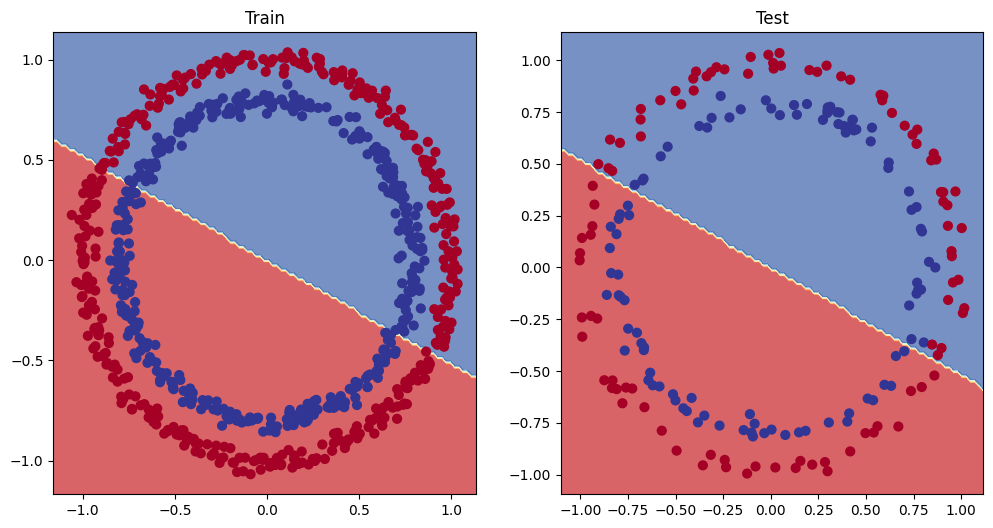

In [ ]:
# plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, x_train, y_train)
plt.subplot(1 ,2, 2)
plt.title("Test")
plot_decision_boundary(model_0, x_test, y_test)

### 5. Improving a model( from a model perspective)

* add more layers-give the model more chances to learn about patterns in the data

* Add more hidden units - go from 5 hidden units to 10 hidden units

* Fit for longer
* changing the activation functions
* changing the learning rate
* fitting for loger


In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5430,  0.5883],
                      [-0.1854,  0.6383],
                      [-0.1610,  0.1392],
                      [-0.3330,  0.4216],
                      [ 0.6160, -0.5229]])),
             ('0.bias', tensor([0.6106, 0.1642, 0.5307, 0.0772, 0.3524])),
             ('1.weight',
              tensor([[-0.0567,  0.3475,  0.1184, -0.1952,  0.1273]])),
             ('1.bias', tensor([-0.1149]))])

In [ ]:
# create a larger model
class CircleModelV1(nn.Module):
  def __init__(self):
     super().__init__()
     self.layer_1 = nn.Linear(in_features=2, out_features=10)
     self.layer_2 = nn.Linear(in_features=10, out_features=10)
     self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    z = self.layer_1(x)
    z = self.layer_2(z)
    z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5430,  0.5883],
                      [-0.1854,  0.6383],
                      [-0.1610,  0.1392],
                      [-0.3330,  0.4216],
                      [ 0.6160, -0.5229]])),
             ('0.bias', tensor([0.6106, 0.1642, 0.5307, 0.0772, 0.3524])),
             ('1.weight',
              tensor([[-0.0567,  0.3475,  0.1184, -0.1952,  0.1273]])),
             ('1.bias', tensor([-0.1149]))])

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
# create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [ ]:

# write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# train for longer
epochs = 1000
# put data on the training device
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ### Training
  model_1.train()
  # 1. forward pass
  y_logits = model_1(x_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2.calculate the loss/acc
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
  # 3. optimizer zero grad
  optimizer.zero_grad()

  # 4.Loss backward (backpropagation)
  loss.backward()
  # 5.optimizer step(gradient decent)
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_1(x_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # 2. calculate the loss
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred= test_pred)

    # print out wha's happen
    if epoch % 100==0:
      print(f"Epoch: {epoch} | Loss: {loss:5f}, Test loss: {test_loss:5f}, Test acc: {test_acc:2f}")


Epoch: 0 | Loss: 0.693955, Test loss: 0.692615, Test acc: 51.000000
Epoch: 100 | Loss: 0.693048, Test loss: 0.693790, Test acc: 48.000000
Epoch: 200 | Loss: 0.692986, Test loss: 0.694373, Test acc: 46.000000
Epoch: 300 | Loss: 0.692980, Test loss: 0.694577, Test acc: 45.000000
Epoch: 400 | Loss: 0.692980, Test loss: 0.694645, Test acc: 46.000000
Epoch: 500 | Loss: 0.692980, Test loss: 0.694668, Test acc: 46.000000
Epoch: 600 | Loss: 0.692980, Test loss: 0.694676, Test acc: 46.000000
Epoch: 700 | Loss: 0.692980, Test loss: 0.694678, Test acc: 46.000000
Epoch: 800 | Loss: 0.692980, Test loss: 0.694679, Test acc: 46.000000
Epoch: 900 | Loss: 0.692980, Test loss: 0.694679, Test acc: 46.000000


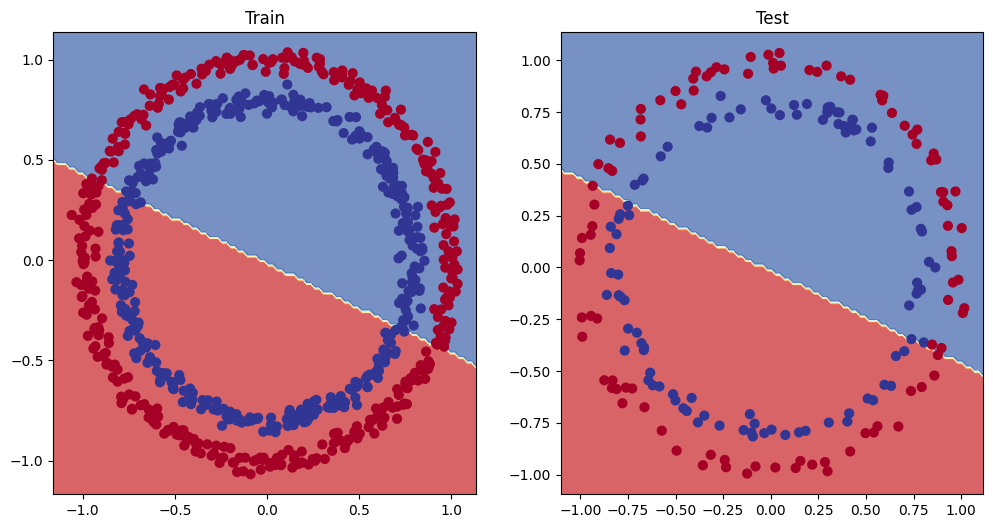

In [ ]:
# plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, x_train, y_train)
plt.subplot(1 ,2, 2)
plt.title("Test")
plot_decision_boundary(model_1, x_test, y_test)

### 5.1 Preparing data to see if our model can fit a straight line

In [ ]:
# create some data
weight = 0.7
bias = 0.3
start = 0
end =1
step = 0.01

# Create data
x_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight*x_regression+bias

# check the data
print(len(x_regression))
x_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
# Create train and test splits
train_split = int(0.8*len(x_regression))
x_train_regression, y_train_regression = x_regression[:train_split], y_regression[:train_split]
x_test_regression, y_test_regression = x_regression[train_split:], y_regression[train_split:]

# check the length of each
len(x_train_regression), len(x_test_regression), len(y_train_regression), len(y_test_regression)


(80, 20, 80, 20)

(None,)

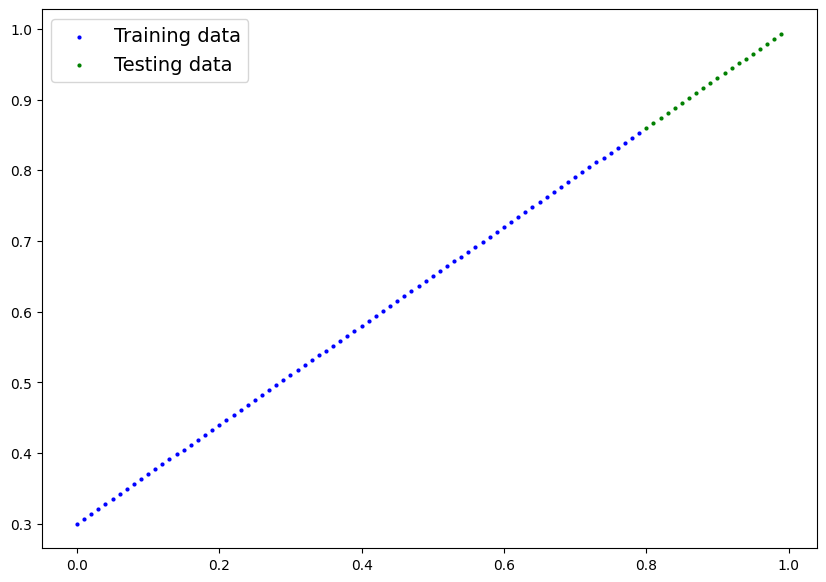

In [ ]:
plot_predictions(train_data=x_train_regression,
                 train_labels=y_train_regression,
                 test_data=x_test_regression,
                 test_labels=y_test_regression),

In [ ]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

### 5.2 Adjusting 'model_1' to fit a strifgt line

In [ ]:
# same architecture as model_1
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss function and optimizer
loss_fn =nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)



In [ ]:
# train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# put the data on the target device
x_train_regression, y_train_regression = x_train_regression.to(device), y_train_regression.to(device)
x_test_regression, y_test_regression = x_test_regression.to(device), y_test_regression.to(device)

# Training & Evaluation loop
for epoch in range(epochs):
    ### Training
    model_2.train()
    y_pred = model_2(x_train_regression)
    loss = loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing (INDENT THIS INSIDE THE LOOP)
    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(x_test_regression)
        test_loss = loss_fn(test_pred, y_test_regression)

        # Print every 100 epochs
        if epoch % 100 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75986 | Test loss: 0.54143
Epoch: 100 | Loss: 0.09309 | Test loss: 0.02901
Epoch: 200 | Loss: 0.07376 | Test loss: 0.02850
Epoch: 300 | Loss: 0.06745 | Test loss: 0.00615
Epoch: 400 | Loss: 0.06107 | Test loss: 0.02004
Epoch: 500 | Loss: 0.05698 | Test loss: 0.01061
Epoch: 600 | Loss: 0.04857 | Test loss: 0.01326
Epoch: 700 | Loss: 0.06109 | Test loss: 0.02127
Epoch: 800 | Loss: 0.05599 | Test loss: 0.01426
Epoch: 900 | Loss: 0.05571 | Test loss: 0.00603


In [ ]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    import matplotlib.pyplot as plt

    # Move everything to CPU before converting
    train_data = train_data.cpu().numpy()
    train_labels = train_labels.cpu().numpy()
    test_data = test_data.cpu().numpy()
    test_labels = test_labels.cpu().numpy()

    if predictions is not None:
        predictions = predictions.cpu().numpy()

    plt.figure(figsize=(10, 7))

    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14})
    plt.show()


### 6 The missing piece: non-linearity

#### 6.1 Recreating non-linear data

(<matplotlib.collections.PathCollection at 0x7d54e930aea0>,)

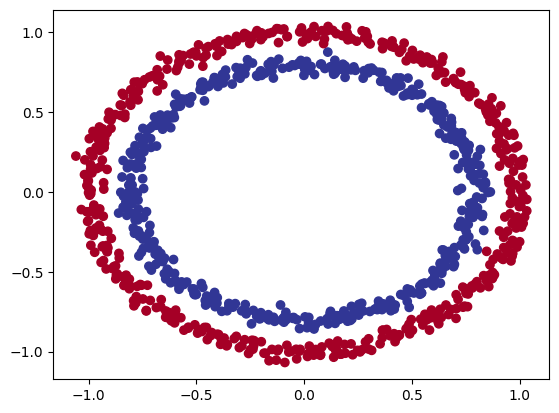

In [ ]:
# make and plot
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

x, y = make_circles(n_samples,
                    noise =0.03,
                    random_state=42)
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlBu),


In [ ]:
# convert data to tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split
# Turn data into tensors
x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

x_train[:5], y_train[:5]


(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.1 Building a Model Wth non Linearity
* Linear=straigh linear
* Non-linear= non-straight lines

In [ ]:
# Build a model with non-linear activiation functions
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    # where should we put our non-linear activation function?
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
# setup the loss and optimizer
loss_fn=nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),
                            lr=0.1)


### 6.3 Training a Model with non-linearity

In [ ]:
# Random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# put all data on target device
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

# Loop through data
epochs = 1000
for epoch in range(epochs):
  ### Training
  model_3.train()

  # 1. forward pass
  y_logits = model_3(x_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2.calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  # 3. optimizer to zero grad
  optimizer.zero_grad()

  # 4.loss bacward
  loss.backward()

  # 5. Step the optimizer
  optimizer.step()

  ### Testing
  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(x_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

    # print out what's happen
    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test loss: {test_loss:.4f}, Test acc: {test_acc:.2f}")




Epoch: 0 | Loss: 0.6929 | Test loss: 0.6932, Test acc: 50.00
Epoch: 100 | Loss: 0.6912 | Test loss: 0.6910, Test acc: 52.50
Epoch: 200 | Loss: 0.6898 | Test loss: 0.6894, Test acc: 55.00
Epoch: 300 | Loss: 0.6879 | Test loss: 0.6872, Test acc: 56.00
Epoch: 400 | Loss: 0.6852 | Test loss: 0.6841, Test acc: 56.50
Epoch: 500 | Loss: 0.6810 | Test loss: 0.6794, Test acc: 56.50
Epoch: 600 | Loss: 0.6751 | Test loss: 0.6729, Test acc: 56.00
Epoch: 700 | Loss: 0.6666 | Test loss: 0.6632, Test acc: 59.00
Epoch: 800 | Loss: 0.6516 | Test loss: 0.6476, Test acc: 67.50
Epoch: 900 | Loss: 0.6236 | Test loss: 0.6215, Test acc: 79.00


### 6.4 Evaluating a model traind with non-linear activation functions.

In [ ]:
# make a predictions
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(x_test))).squeeze()

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

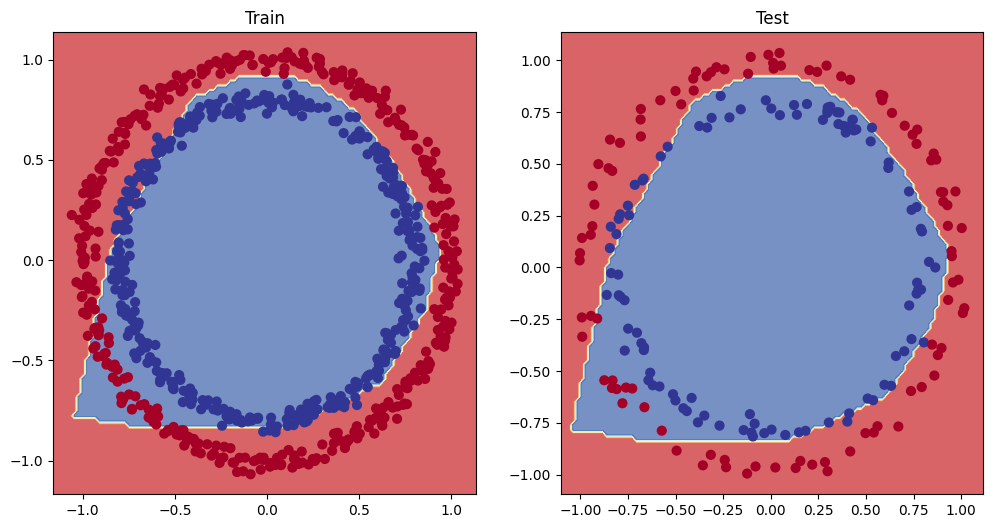

In [ ]:
# plot decision prediction
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, x_test, y_test)

### 7. Replicating non-linear activation functions.

In [ ]:
# create a tensor
A = torch.arange(-10, 10, 1)
A.dtype

torch.int64

In [ ]:
A

tensor([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,
          4,   5,   6,   7,   8,   9])

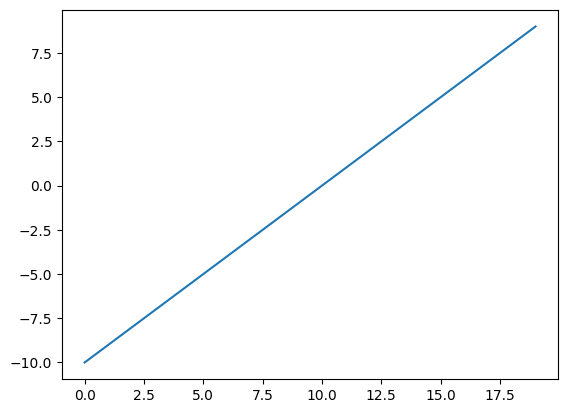

In [ ]:
# visualize the tensor
plt.plot(A)

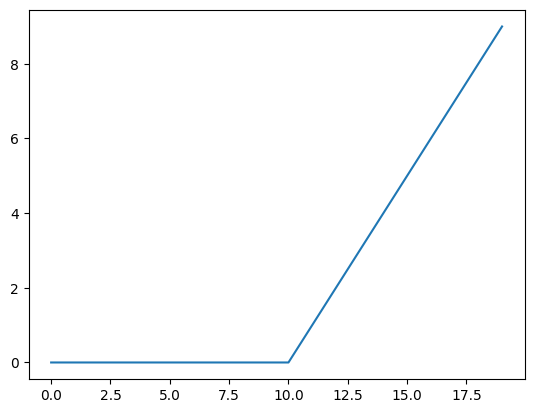

In [ ]:
plt.plot(torch.relu(A))

In [ ]:
def relu(A):
  return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([[0.7542, 0.2315],
        [0.0000, 0.1533],
        [0.0000, 0.1733],
        ...,
        [0.0000, 0.0000],
        [0.6704, 0.0000],
        [0.2811, 0.9638]])

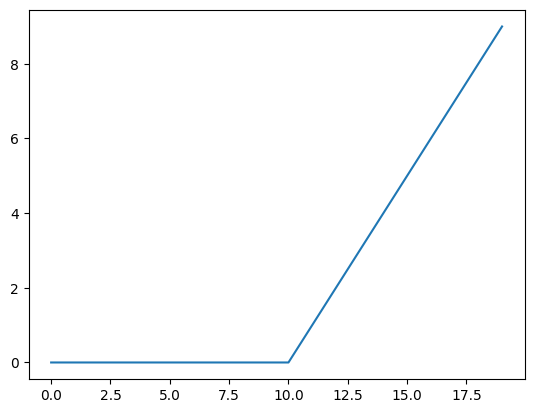

In [ ]:
# plot ReLU activation function
plt.plot(torch.relu(A))

In [ ]:
# now let's do the same for sigmoid
def sigmoid(x):
  return 1/(1+torch.exp(A))

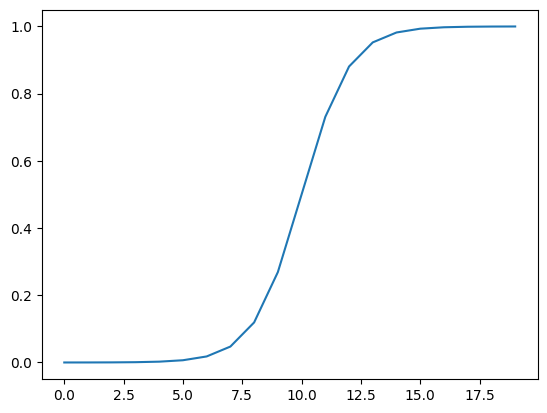

In [ ]:
plt.plot(torch.sigmoid(A))

### 8.putting it all together with a muli-class calassification problem


(<matplotlib.collections.PathCollection at 0x7d54e904de50>,)

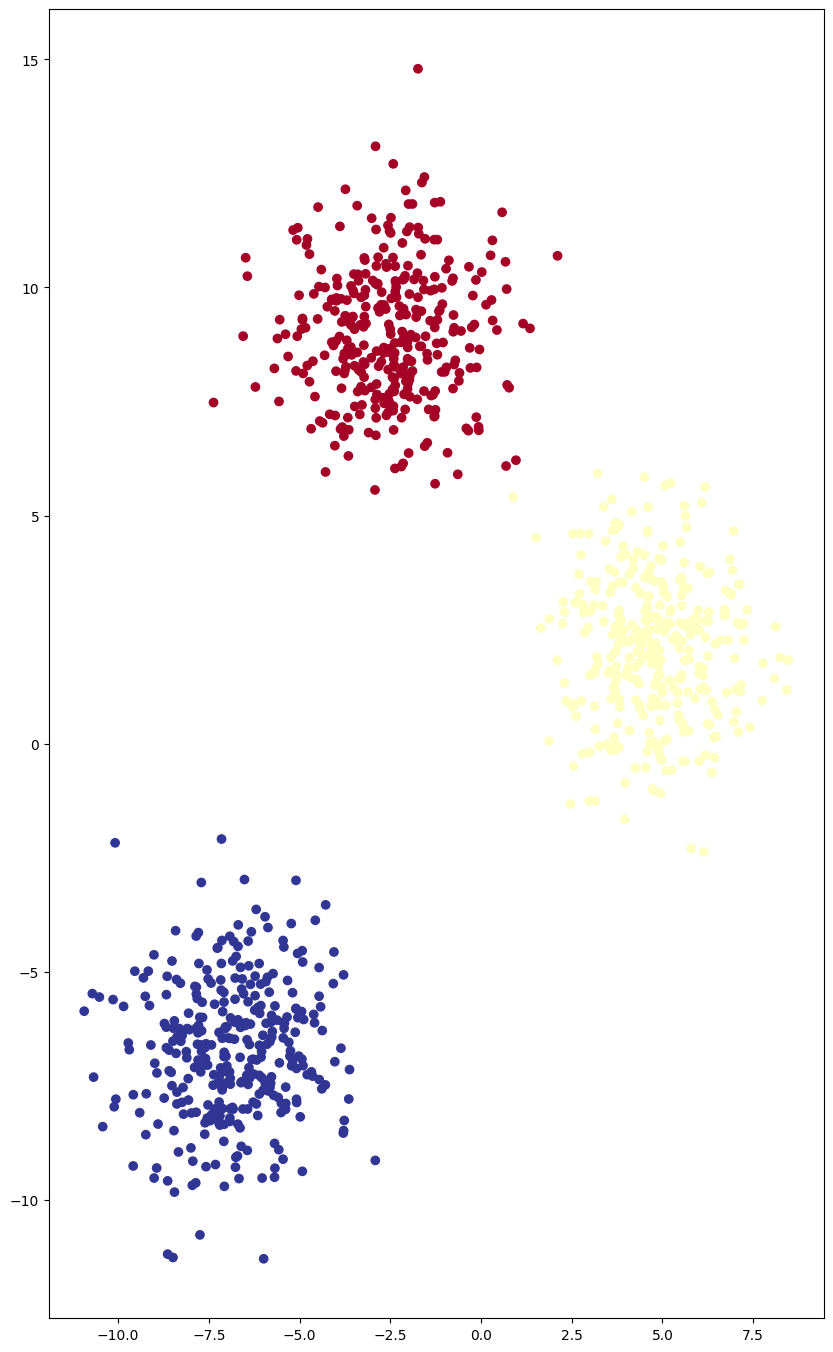

In [ ]:
# import depencecies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# set the hyperparameter for datta creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. create multi- class data
x_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

# 2. Turn data into tensors
x_blob = torch.from_numpy(x_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

# 3. split into train and test set
x_blob_train, x_blob_test, y_blob_train, y_blob_test = train_test_split(x_blob,
                                                           y_blob,
                                                           test_size=0.2,
                                                           random_state=RANDOM_SEED)


# 4. plot data visualization

plt.figure(figsize=(10, 17))
plt.scatter(x_blob[:, 0], x_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu),

### 8.2 Building Multi-class classification model in pytorch.

In [ ]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self,input_features, out_features, hidden_units=8):

    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=out_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel( input_features=2,
                    out_features=4,
                    hidden_units=8).to(device)


model_4




BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
x_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1., 0., 1., 1., 0.]))

### 8.3 Create a loss function and an optimizer for a multi-class classification model.

In [ ]:
# create a loss function for multi-class classification
loss_fn=nn.CrossEntropyLoss()

# create an optimizer for multi-class classification
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)


### 8.4 Getting prediction probabilities for a multi-class pytorch model

In [ ]:
# Let's get
next(model_4.parameters()).device

device(type='cuda', index=0)

In [ ]:
# let's get some raw outputs of our model (logits)
model_4.eval()
with torch.inference_mode():
  y_preds = model_4(x_blob_test.to(device))


y_preds[:10]


tensor([[-0.3418, -1.4530, -1.2354, -0.3702],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [ 0.2450, -0.2432,  0.1663,  0.0092],
        [-0.8443, -0.7882, -1.5777, -1.0264],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [-0.2103, -0.4405, -0.6034, -0.5230],
        [-0.2329, -1.2120, -0.9849, -0.3004]], device='cuda:0')

In [ ]:
y_blob_test[:10]

tensor([0., 2., 2., 1., 0., 2., 1., 0., 1., 0.])

In [ ]:
# Convert logits to probabilities (multi-class)
y_preds= torch.argmax(y_logits, dim=-1)
y_preds

tensor(553, device='cuda:0')

In [ ]:
y_blob_test

tensor([0., 2., 2., 1., 0., 2., 1., 0., 1., 0., 0., 1., 0., 0., 0., 2., 2., 1.,
        2., 2., 2., 0., 0., 1., 1., 1., 2., 0., 1., 0., 2., 1., 1., 2., 1., 1.,
        1., 2., 0., 1., 0., 2., 2., 1., 0., 2., 1., 1., 0., 2., 1., 0., 0., 1.,
        2., 2., 0., 0., 2., 1., 1., 0., 2., 1., 2., 0., 0., 2., 2., 0., 0., 2.,
        2., 2., 1., 2., 2., 2., 2., 1., 0., 2., 2., 1., 2., 2., 1., 2., 2., 1.,
        2., 2., 0., 2., 2., 2., 1., 0., 2., 1., 0., 0., 2., 0., 2., 2., 0., 0.,
        2., 1., 1., 1., 0., 2., 1., 2., 0., 0., 1., 2., 1., 2., 0., 1., 1., 0.,
        0., 0., 2., 2., 1., 1., 2., 2., 0., 2., 0., 0., 0., 1., 0., 0., 1., 1.,
        2., 2., 0., 2., 2., 2., 1., 0., 2., 1., 0., 0., 2., 2., 1., 1., 1., 0.,
        2., 1., 0., 2., 2., 0., 2., 2., 1., 0., 2., 1., 1., 1., 0., 1., 2., 1.,
        0., 1., 2., 1., 1., 1., 0., 1., 1., 2., 0., 0., 0., 2., 1., 0., 2., 0.,
        2., 0.])

### 8.5 create a training loop and testing loop for multi-class pytorch model.

In [ ]:
# fit the multi-class model to the data
import torch

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set number of epochs
epochs = 1000

# move data to device + FIX labels dtype
x_blob_train = x_blob_train.to(device)
y_blob_train = y_blob_train.to(device).long()   # ✅ FIX

x_blob_test = x_blob_test.to(device)
y_blob_test = y_blob_test.to(device).long()     # ✅ FIX

# Loop through data
for epoch in range(epochs):

    ### Training
    model_4.train()

    # forward pass (FIXED)
    y_logits = model_4(x_blob_train)

    # predictions
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    # loss (NO softmax here)
    loss = loss_fn(y_logits, y_blob_train)

    # accuracy
    acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #### Testing
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(x_blob_test)

        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, y_blob_test)

        # FIXED variable
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_preds)

    # print progress
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | "
              f"Loss: {loss:.4f}, Acc: {acc:.2f} | "
              f"Test Loss: {test_loss:.6f}, Test Acc: {test_acc:.5f}%")


Epoch: 0 | Loss: 1.1719, Acc: 50.50 | Test Loss: 1.003090, Test Acc: 62.00000%
Epoch: 100 | Loss: 0.0076, Acc: 99.88 | Test Loss: 0.005920, Test Acc: 100.00000%
Epoch: 200 | Loss: 0.0045, Acc: 99.88 | Test Loss: 0.003034, Test Acc: 100.00000%
Epoch: 300 | Loss: 0.0037, Acc: 99.88 | Test Loss: 0.002212, Test Acc: 100.00000%
Epoch: 400 | Loss: 0.0034, Acc: 99.88 | Test Loss: 0.001793, Test Acc: 100.00000%
Epoch: 500 | Loss: 0.0031, Acc: 99.88 | Test Loss: 0.001529, Test Acc: 100.00000%
Epoch: 600 | Loss: 0.0030, Acc: 99.88 | Test Loss: 0.001342, Test Acc: 100.00000%
Epoch: 700 | Loss: 0.0029, Acc: 99.88 | Test Loss: 0.001202, Test Acc: 100.00000%
Epoch: 800 | Loss: 0.0028, Acc: 99.88 | Test Loss: 0.001090, Test Acc: 100.00000%
Epoch: 900 | Loss: 0.0027, Acc: 99.88 | Test Loss: 0.000999, Test Acc: 100.00000%


### 8.6 Making and valuating predictions with a pytorch multi-class model

In [ ]:
# make predictions
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(x_blob_test)

# view the first 10 predictions
y_logits[:10]

tensor([[ 7.2173, -6.3094, -8.2887, -7.9681],
        [-4.2608, -4.5903,  5.8267, -4.6906],
        [-4.4958, -4.8280,  6.0806, -4.9376],
        [-3.9757,  7.4314, -3.8889, -4.4189],
        [ 5.4915, -3.4012, -8.0255, -7.6681],
        [-4.6693, -5.0486,  6.3401, -5.1339],
        [-6.5939, 12.3817, -6.7479, -6.8936],
        [ 5.7150, -5.0159, -6.3666, -6.3399],
        [-2.5827,  5.0076, -2.6784, -3.3548],
        [ 5.8481, -5.0675, -6.5443, -6.4790]], device='cuda:0')

In [ ]:
# Go from logits
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs

tensor([[1.0000e+00, 1.3348e-06, 1.8442e-07, 2.5414e-07],
        [4.1595e-05, 2.9918e-05, 9.9990e-01, 2.7064e-05],
        [2.5509e-05, 1.8299e-05, 9.9994e-01, 1.6399e-05],
        [1.1116e-05, 9.9997e-01, 1.2124e-05, 7.1365e-06],
        [9.9986e-01, 1.3737e-04, 1.3477e-06, 1.9266e-06],
        [1.6545e-05, 1.1323e-05, 9.9996e-01, 1.0396e-05],
        [5.7409e-09, 1.0000e+00, 4.9217e-09, 4.2541e-09],
        [9.9997e-01, 2.1857e-05, 5.6623e-06, 5.8154e-06],
        [5.0471e-04, 9.9880e-01, 4.5865e-04, 2.3320e-04],
        [9.9997e-01, 1.8171e-05, 4.1499e-06, 4.4299e-06],
        [9.9993e-01, 4.3526e-05, 1.4275e-05, 1.3389e-05],
        [7.3051e-08, 1.0000e+00, 3.0030e-09, 3.4106e-09],
        [9.9997e-01, 2.6256e-05, 1.1516e-06, 1.5342e-06],
        [9.9999e-01, 4.4875e-06, 7.9460e-07, 9.6928e-07],
        [1.0000e+00, 1.8304e-06, 2.5032e-07, 3.3988e-07],
        [1.1777e-04, 8.8095e-05, 9.9971e-01, 7.9335e-05],
        [3.1806e-05, 2.2635e-05, 9.9993e-01, 2.0507e-05],
        [2.684

In [ ]:
y_blob_test

tensor([0, 2, 2, 1, 0, 2, 1, 0, 1, 0, 0, 1, 0, 0, 0, 2, 2, 1, 2, 2, 2, 0, 0, 1,
        1, 1, 2, 0, 1, 0, 2, 1, 1, 2, 1, 1, 1, 2, 0, 1, 0, 2, 2, 1, 0, 2, 1, 1,
        0, 2, 1, 0, 0, 1, 2, 2, 0, 0, 2, 1, 1, 0, 2, 1, 2, 0, 0, 2, 2, 0, 0, 2,
        2, 2, 1, 2, 2, 2, 2, 1, 0, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 0, 2, 2, 2,
        1, 0, 2, 1, 0, 0, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 0, 2, 1, 2, 0, 0, 1, 2,
        1, 2, 0, 1, 1, 0, 0, 0, 2, 2, 1, 1, 2, 2, 0, 2, 0, 0, 0, 1, 0, 0, 1, 1,
        2, 2, 0, 2, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 1, 1, 1, 0, 2, 1, 0, 2, 2, 0,
        2, 2, 1, 0, 2, 1, 1, 1, 0, 1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 2, 0, 0,
        0, 2, 1, 0, 2, 0, 2, 0], device='cuda:0')

In [ ]:
# Go from pred probs to pred labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([0, 2, 2, 1, 0, 2, 1, 0, 1, 0], device='cuda:0')

In [ ]:
y_blob_test

tensor([0, 2, 2, 1, 0, 2, 1, 0, 1, 0, 0, 1, 0, 0, 0, 2, 2, 1, 2, 2, 2, 0, 0, 1,
        1, 1, 2, 0, 1, 0, 2, 1, 1, 2, 1, 1, 1, 2, 0, 1, 0, 2, 2, 1, 0, 2, 1, 1,
        0, 2, 1, 0, 0, 1, 2, 2, 0, 0, 2, 1, 1, 0, 2, 1, 2, 0, 0, 2, 2, 0, 0, 2,
        2, 2, 1, 2, 2, 2, 2, 1, 0, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 0, 2, 2, 2,
        1, 0, 2, 1, 0, 0, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 0, 2, 1, 2, 0, 0, 1, 2,
        1, 2, 0, 1, 1, 0, 0, 0, 2, 2, 1, 1, 2, 2, 0, 2, 0, 0, 0, 1, 0, 0, 1, 1,
        2, 2, 0, 2, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 1, 1, 1, 0, 2, 1, 0, 2, 2, 0,
        2, 2, 1, 0, 2, 1, 1, 1, 0, 1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 2, 0, 0,
        0, 2, 1, 0, 2, 0, 2, 0], device='cuda:0')

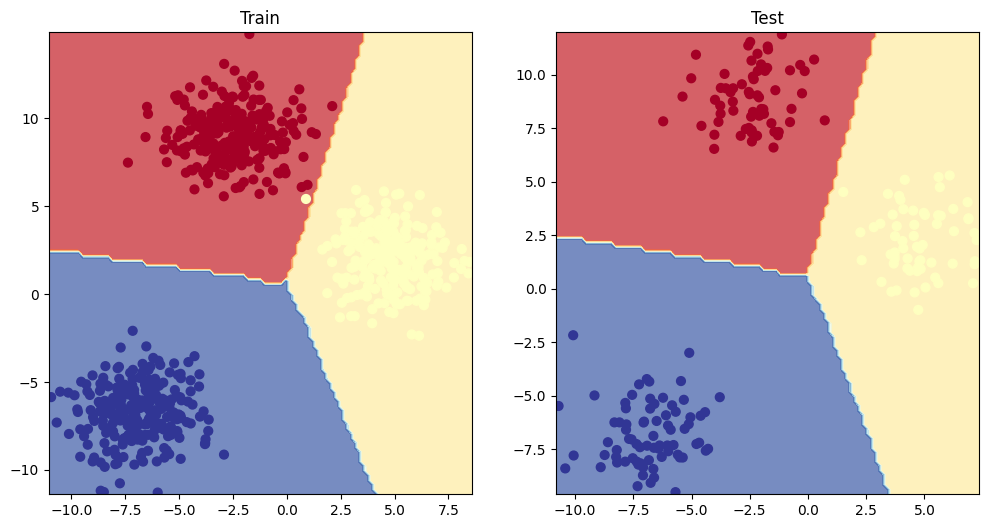

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, x_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, x_blob_test, y_blob_test)

### 9. A few more classification metrics...(to evaluate our classification model)

* Accuracy
* Precision
* Recall
* F1-score
* Classification report

In [ ]:
!pip install torchmetrics

In [ ]:
from torchmetrics import Accuracy
num_classes = 3  # example: change this to your actual number
torchmetric_accuracy = Accuracy(task="multiclass", num_classes=num_classes).to(device)
print(acc)

99.875


04_Pytorch_Computer_Vision